Verify that the data of your personal project have at least 2 continuous and 2 categorical or discrete variables. 
Otherwise change data.
With your data, proceed to the three analyses you did during the tutorial 1.

Understand data as actual values of random variables; Choose 2 variables of your project and make a probability model of them by assuming that each observation has been obtained by a simple random sampling (i.e. by drawing units uniformly with replacement in the population). Display a frequency table for your variables. Give explicitly the random variables involved and their expression in terms of your sample. What is the joint distribution of the frequencies displayed in the table ? 

The size of the sample, the number of classes and the notations must be clear. 
Proceed to a simple regression with 2 CONTINUOUS variables of your dataset. In this first part, you will write the model with all the assumptions (theoretical results must be written as a markdown), continue with the estimation of parameters, the regression line with all the necessary plots, CI for the prediction and the mean prediction. Outliers and residual analysis must be included. Make a decision about outliers (keep them or erase them from the set). 

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

In [90]:
import numpy as np
import scipy.stats as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv('spotify.csv')
df

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [92]:
#sns.pairplot(df.sample(n=300))

In [93]:

corrcoef_table = df[["popularity","duration_ms","danceability","energy","loudness","speechiness","acousticness","liveness","valence","tempo"]].corr()

strong_corr = corrcoef_table.where((corrcoef_table > 0.6) | (corrcoef_table < -0.6))
strong_corr

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,liveness,valence,tempo
popularity,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_ms,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energy,NaN,NaN,NaN,1.000000,0.76169,NaN,-0.733906,NaN,NaN,NaN
loudness,NaN,NaN,NaN,0.761690,1.00000,NaN,NaN,NaN,NaN,NaN
speechiness,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
acousticness,NaN,NaN,NaN,-0.733906,NaN,NaN,1.000000,NaN,NaN,NaN
liveness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
tempo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


from this table , we can see that the only values that have a supposed correlation are :
energy/loudness & energy/acousticnesss –––––––––––– So we'll keep those 

### Data cleaning time, were only going to keep the track info and two categorical and three numerical variables 
here we decided to chose :
#### 3 numerical continuous variables
- **energy** : Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale

- **loudness** : The overall loudness of a track in decibels (dB)

- **acousticness** : A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic

#### 2 categorical variables
- **key** : The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1

- **track_genre** : The genre in which the track belongs


--- *source : kaggle description of the dataset* ---

### Making the dataset less big 
we have a little problem , if we try to find correlations right now we encounter 2 subproblems :
1. Because there is 114k rows the calculations are very costly
2. Because there are so much values if we plot anything we will not be able to see any correlation

SO we sample n = 1000

In [94]:
spotify = df[["artists","album_name","track_name","energy","loudness","acousticness","key","track_genre"]]
spotify = spotify.sample(n=1000) 
spotify = spotify.reset_index()
spotify = spotify.drop("index",axis=1)
spotify

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
0,keshi,bandaids,right here,0.496,-9.441,0.083900,5,chill
1,Format:B,Rocket Bunny,Rocket Bunny,0.811,-7.043,0.000438,6,minimal-techno
2,Matheus & Kauan,10 Anos Na Praia (Ao Vivo),Solteiros Também Amam - Ao Vivo,0.574,-8.886,0.661000,10,sertanejo
3,Enamour;Meliha,Say Hello EP,Say Hello,0.766,-8.688,0.035500,0,progressive-house
4,Jimmy Buffett,Best 70s Rock Tunes,Survive,0.130,-16.808,0.399000,0,singer-songwriter
...,...,...,...,...,...,...,...,...
995,Lynyrd Skynyrd,Second Helping (Expanded Edition),Sweet Home Alabama,0.605,-12.145,0.181000,7,blues
996,Richie Hawtin;F.U.S.E.,From My Mind to Yours,Them,0.510,-12.562,0.373000,1,detroit-techno
997,Digicult;U-Recken,Soul Samadhi,Sundara - Original Mix,0.820,-4.742,0.000045,1,trance
998,Kenshi Yonezu,M八七,M八七,0.719,-8.329,0.300000,1,anime


/Users/enzoducros/Library/Python/3.9/lib/python/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


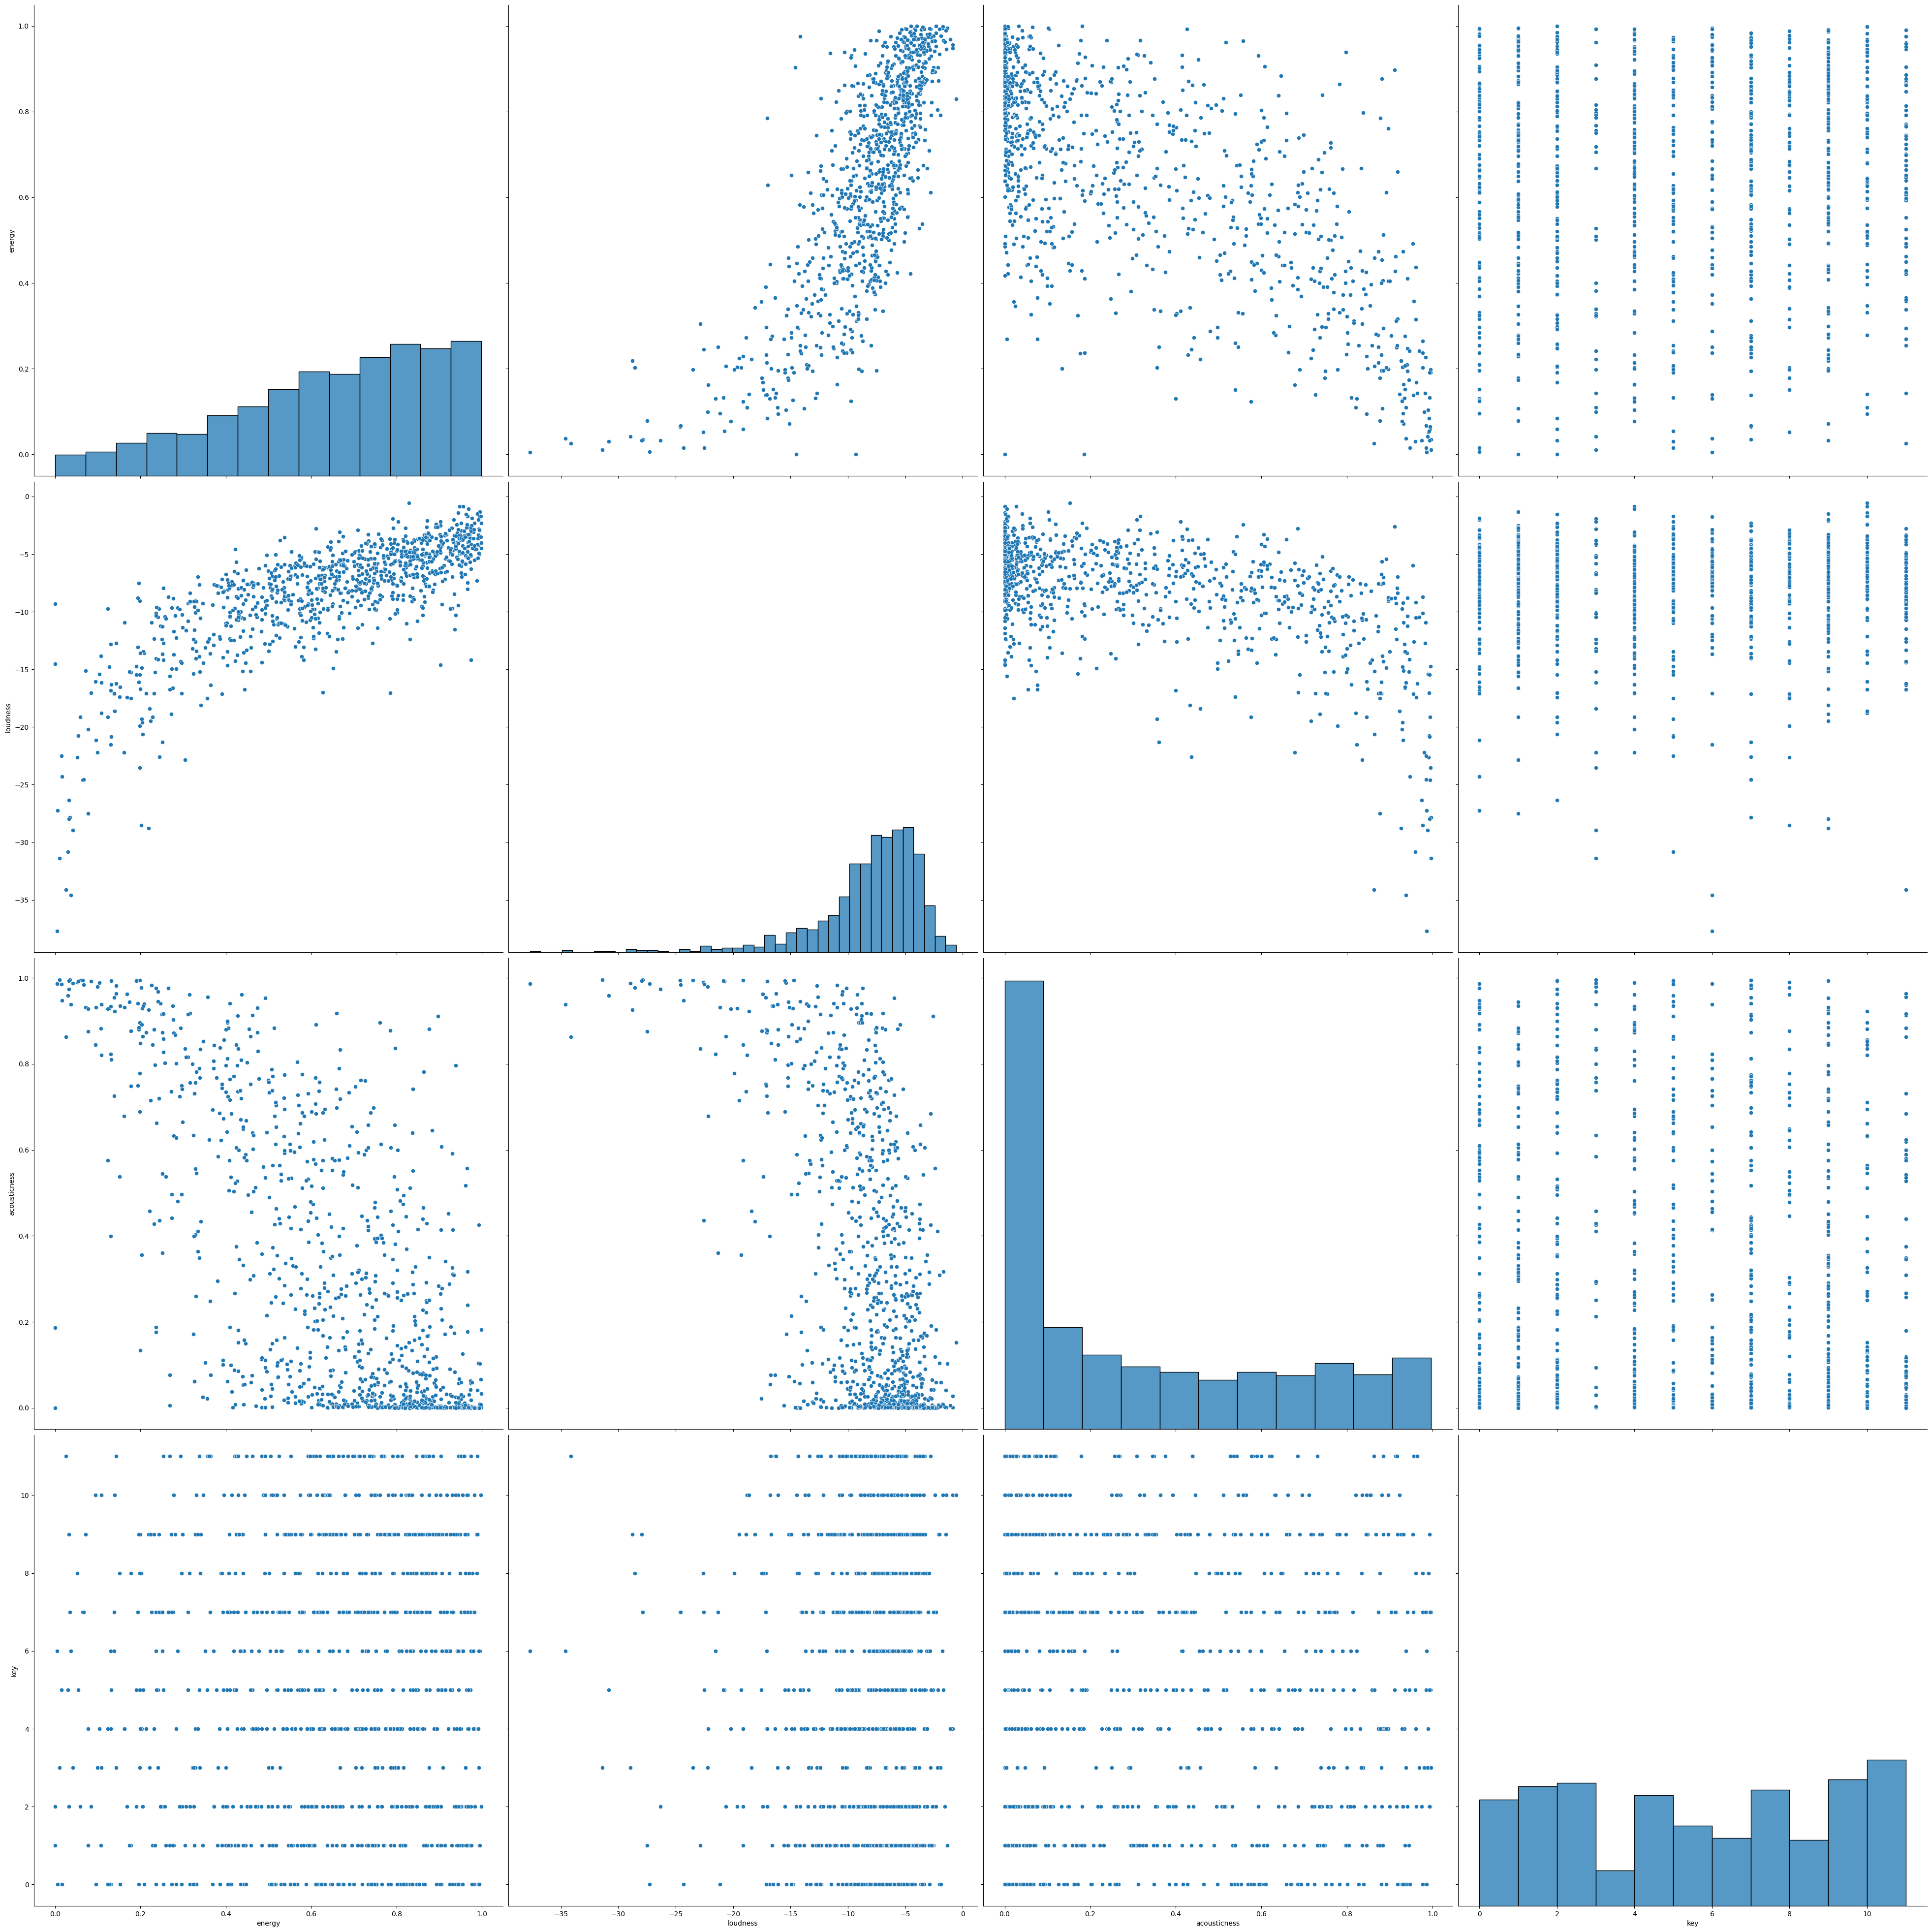

In [95]:
#fig , ax = plt.subplots(figsize =(10,7),dpi=100)
spotify.iloc[:,3:]
sns.pairplot(spotify.iloc[:,3:],size=10)

 We can observe an exponential relation in between loudness & energy, so if we linearise the model we might just find a lienar model 

# LINEAR REGRESSION - hell yeah
1. linearization
2. linear regression

<Axes: xlabel='loudness', ylabel='energy'>

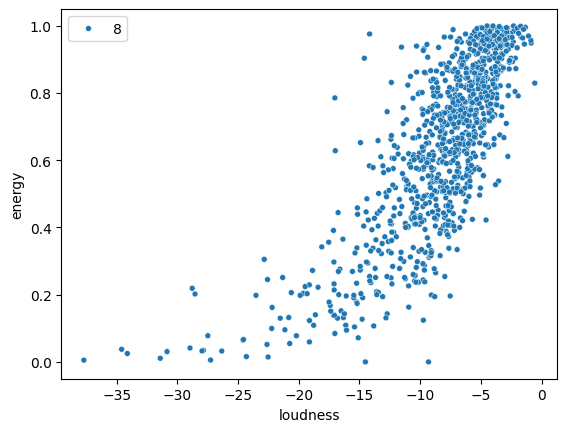

In [96]:
spotify_lr = spotify[["loudness","energy"]] # first we only take the two 
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size=8)

In [97]:
np.corrcoef(x=spotify_lr.loudness,y=spotify_lr.energy)

array([[1.        , 0.77461512],
       [0.77461512, 1.        ]])

# STOP HERE AND PASS ON BECAUSE LINEARIZATION KILLS THE CORR

**1. Linearisation**

In [98]:
'''# to linearise , we'll apply a map to the y value
spotify_lr["energy"] = spotify_lr["energy"].map(np.log)
spotify_lr
'''

'# to linearise , we\'ll apply a map to the y value\nspotify_lr["energy"] = spotify_lr["energy"].map(np.log)\nspotify_lr\n'

In [99]:
'''spotify_lr = spotify_lr.where(spotify_lr > -10)
spotify_lr = spotify_lr.dropna()
spotify_lr'''

'spotify_lr = spotify_lr.where(spotify_lr > -10)\nspotify_lr = spotify_lr.dropna()\nspotify_lr'

In [100]:
'''sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size = 8)
np.corrcoef(spotify_lr.energy,spotify_lr.loudness)
# hey , the corr coefficient is 0.8 , it's good 
'''

"sns.scatterplot(data=spotify_lr,x='loudness',y='energy',size = 8)\nnp.corrcoef(spotify_lr.energy,spotify_lr.loudness)\n# hey , the corr coefficient is 0.8 , it's good \n"

# CONTINUE HERE

**2. Start of Linear Regression**

In [101]:
lr = st.linregress(x=spotify_lr.loudness,y=spotify_lr.energy)
a = lr.intercept
b = lr.slope
coef = [b,a]
boundaries = [-30,0]
lr

LinregressResult(slope=np.float64(0.039965609276503396), intercept=np.float64(0.9723630011621951), rvalue=np.float64(0.7746151207471632), pvalue=np.float64(8.420524174451587e-201), stderr=np.float64(0.0010328795390491382), intercept_stderr=np.float64(0.009809589275451008))

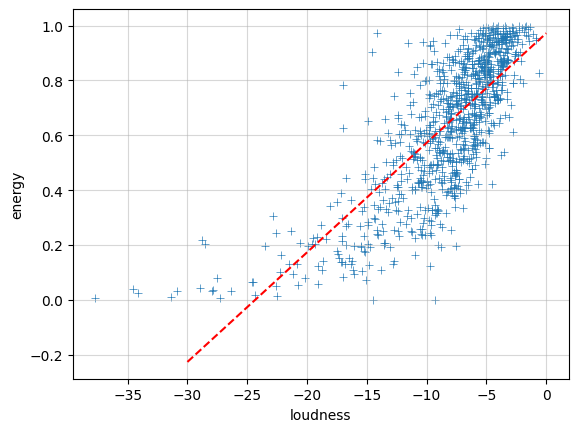

In [102]:
# lets plot this 
line = np.poly1d(coef)
sns.scatterplot(data=spotify_lr,x='loudness',y='energy',marker="+")
plt.plot(boundaries,line(boundaries),'r--')
plt.grid(alpha = 0.5)


## outliers ? 

/var/folders/xl/0wxp8zgx2wz1_sw2nyhksnr00000gn/T/ipykernel_58615/1734155859.py:5: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(z,line(z)+ 2*np.sqrt(hs2),'b-',linestyle='dashed',linewidth = 0.7)
/var/folders/xl/0wxp8zgx2wz1_sw2nyhksnr00000gn/T/ipykernel_58615/1734155859.py:6: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(z,line(z)- 2*np.sqrt(hs2),'b-', linestyle='dashed',linewidth = 0.7)


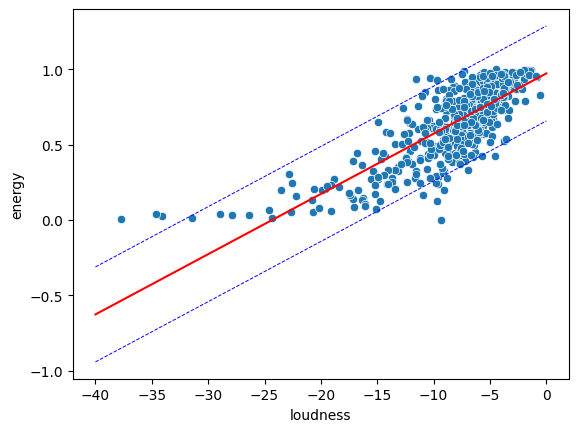

In [103]:
z = [-40,0]
sns.scatterplot(data=spotify.sample(500) , x="loudness" , y="energy" ,markers="*")

plt.plot(z,line(z),'r-')
plt.plot(z,line(z)+ 2*np.sqrt(hs2),'b-',linestyle='dashed',linewidth = 0.7)
plt.plot(z,line(z)- 2*np.sqrt(hs2),'b-', linestyle='dashed',linewidth = 0.7)

<Axes: xlabel='loudness', ylabel='energy'>

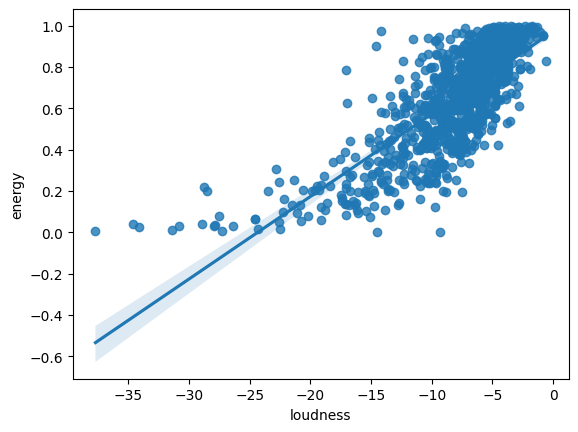

In [104]:
sns.regplot(data=spotify,x='loudness',y='energy')

### continum analysis

In [105]:
x = spotify_lr.loudness
y = spotify_lr.energy
n = len(spotify_lr.loudness)

hy = a+b*x
e = y - hy

sse = np.sum(e**2)
hs2 = sse/(n-2)

residual analysis

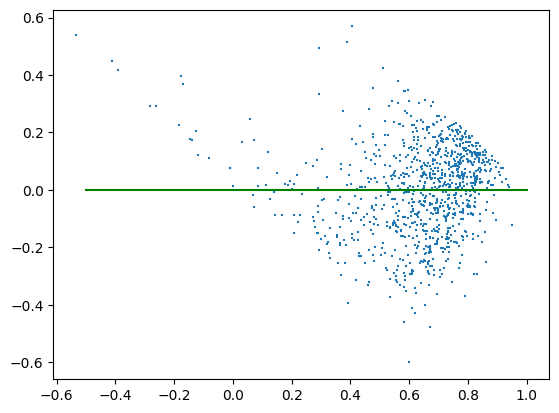

In [106]:
plt.scatter(x=hy,y=e,marker="+",s= 4)
plt.plot([-0.5,1],[0,0],'g')

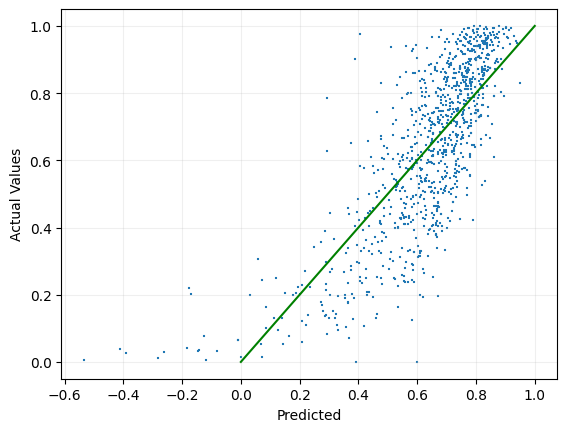

In [107]:
plt.scatter(x=hy,y=y,marker="+",s=7-5)
plt.plot([0,1],[0,1],'g')
plt.xlabel('Predicted')
plt.ylabel('Actual Values')
plt.grid(visible=True,alpha=0.2)

### q-q plot

In [108]:
dist = st.norm(loc=0,scale=np.sqrt(hs2))

Text(0.5, 1.0, 'q-q plot')

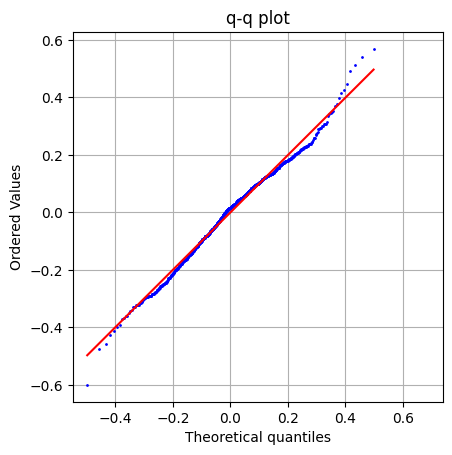

In [109]:
st.probplot(e,dist=dist,plot=plt)
plt.gca().lines[0].set_markersize(1)
plt.axis('square')
plt.grid()
plt.title("q-q plot")

**INterpratation** : the q-q plot is fine , however the residuals express heteroscadisticity , maybe they just have different sigmas. So technically we cannot apply our linear regression

# Anova regression

Proceed to an analysis of variance with 1 DISCRETE or CATEGORICAL variable as input and 1 CONTINUOUS variables as output in your project.
Interpret and comment all your results.

We take the categorical variable of the genre , and the continuous one being the energy 
We also chose 9 genres to make the analysis simpler 

In [110]:
# Only choosing some categories
types_list = ['house','r-n-b','jazz','brazil','emo','acoustic','latino','drum-and-bass','opera']
spotify_Anova = spotify[spotify['track_genre'].isin(types_list)]
spotify_Anova

,artists,album_name,track_name,energy,loudness,acousticness,key,track_genre
31,Marshmello;Jonas Brothers,Leave Before You Love Me,Leave Before You Love Me (with Jonas Brothers),0.738,-4.770,0.002260,7,house
46,Cássia Eller,Acústico (Ao Vivo),Todo Amor Que Houver Nessa Vida - Ao Vivo,0.452,-8.524,0.495000,2,brazil
52,Rory Block,Cried Like A Baby,Cried Like A Baby,0.488,-7.890,0.560000,10,acoustic
53,Four Year Strong,Enemy Of The World,Enemy Of The World,0.987,-4.573,0.000533,9,emo
69,Dean Martin,pov: you are walking in a winter wonderland,"Baby, It's Cold Outside",0.196,-16.093,0.880000,0,jazz
...,...,...,...,...,...,...,...,...
949,J Balvin,Perreo Tenebroso Vol. 4,Reggaeton,0.740,-4.325,0.016500,4,latino
951,Parachute,Losing Sleep,The Mess I Made,0.572,-5.109,0.015800,6,acoustic
974,Antônio Carlos Jobim,Chill in Brazil,Favela,0.224,-19.476,0.715000,9,jazz
976,Kate Bush,OK Boomers - Top Tunes,Wuthering Heights,0.429,-10.007,0.180000,1,r-n-b


In [111]:
spotify_Anova = spotify_Anova[['track_genre','energy']]
spotify_Anova

,track_genre,energy
31,house,0.738
46,brazil,0.452
52,acoustic,0.488
53,emo,0.987
69,jazz,0.196
...,...,...
949,latino,0.740
951,acoustic,0.572
974,jazz,0.224
976,r-n-b,0.429


<Axes: xlabel='track_genre', ylabel='energy'>

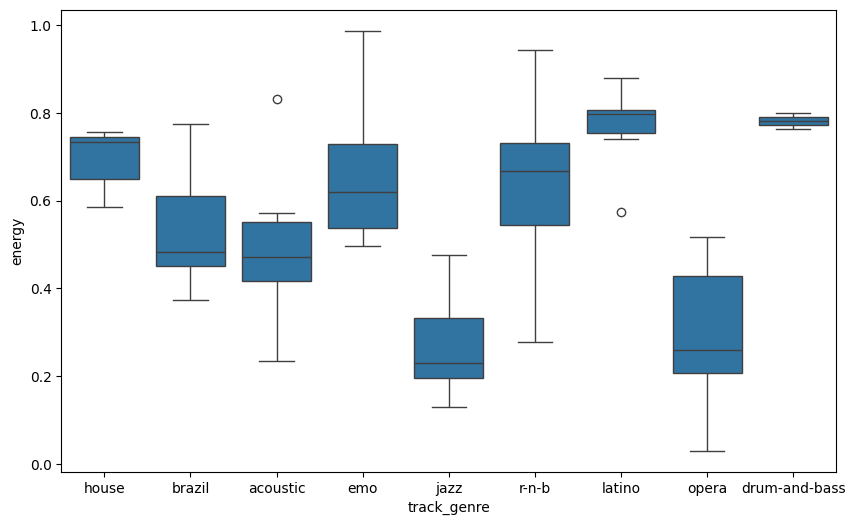

In [124]:
# BOxplottts 
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=spotify_Anova, x="track_genre", y="energy", ax=ax)


Hey , there seems to be a good difference in between types  , and also some that maybe are very similar ( for example drum&Bass and house that are very similar in style so it's not suprising that they have similar boxplots )

## analysis of variance

In [125]:
spotify_Anova.groupby('track_genre').describe()

energy                                                        \
               count      mean       std     min      25%     50%      75%   
track_genre                                                                  
acoustic         6.0  0.497167  0.198889  0.2340  0.41575  0.4710  0.55100   
brazil           9.0  0.536556  0.130360  0.3730  0.45200  0.4830  0.61000   
drum-and-bass    2.0  0.780500  0.026163  0.7620  0.77125  0.7805  0.78975   
emo              9.0  0.672444  0.170504  0.4960  0.53800  0.6190  0.72800   
house            8.0  0.697250  0.066646  0.5850  0.64900  0.7335  0.74400   
jazz             8.0  0.274875  0.123690  0.1310  0.19550  0.2305  0.33350   
latino           6.0  0.765167  0.103980  0.5730  0.75275  0.7970  0.80525   
opera            5.0  0.288540  0.190780  0.0307  0.20700  0.2600  0.42800   
r-n-b           11.0  0.641091  0.195582  0.2780  0.54350  0.6670  0.73200   

                      
                 max  
track_genre           
acoustic       0.832  
brazil         0.774  
drum-and-bass  0.799  
emo            0.987  
house          0.756  
jazz           0.477  
latino         0.878  
opera          0.517  
r-n-b          0.942

#### with an scipy stats function

In [126]:
groups = [g["energy"].to_numpy()for _, g in spotify_Anova.groupby("track_genre")]

anova = st.f_oneway(groups[0],groups[1],groups[2],groups[3],groups[4],groups[5],groups[6],groups[7],groups[8])
print(f"the d statistic is {anova.statistic} with p-value {anova.pvalue}")
print(f" the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O")

the d statistic is 9.244036980093025 with p-value 5.80653825425179e-08
 the statistic is very high and p-value is very low so we can conclude that the track genre does impact energy , we reject H_O
